In [8]:
import pandas as pd

df = pd.read_csv(r"C:/Users/kaism/OneDrive/Documents/Projet Perso/data/Steel_industry_data.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(35040, 11)
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [9]:
# Infos générales
print(df.info())
print("\n")
print(df.describe())
print("\n")
print("Valeurs manquantes :")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [10]:
print(df.columns.tolist())

['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


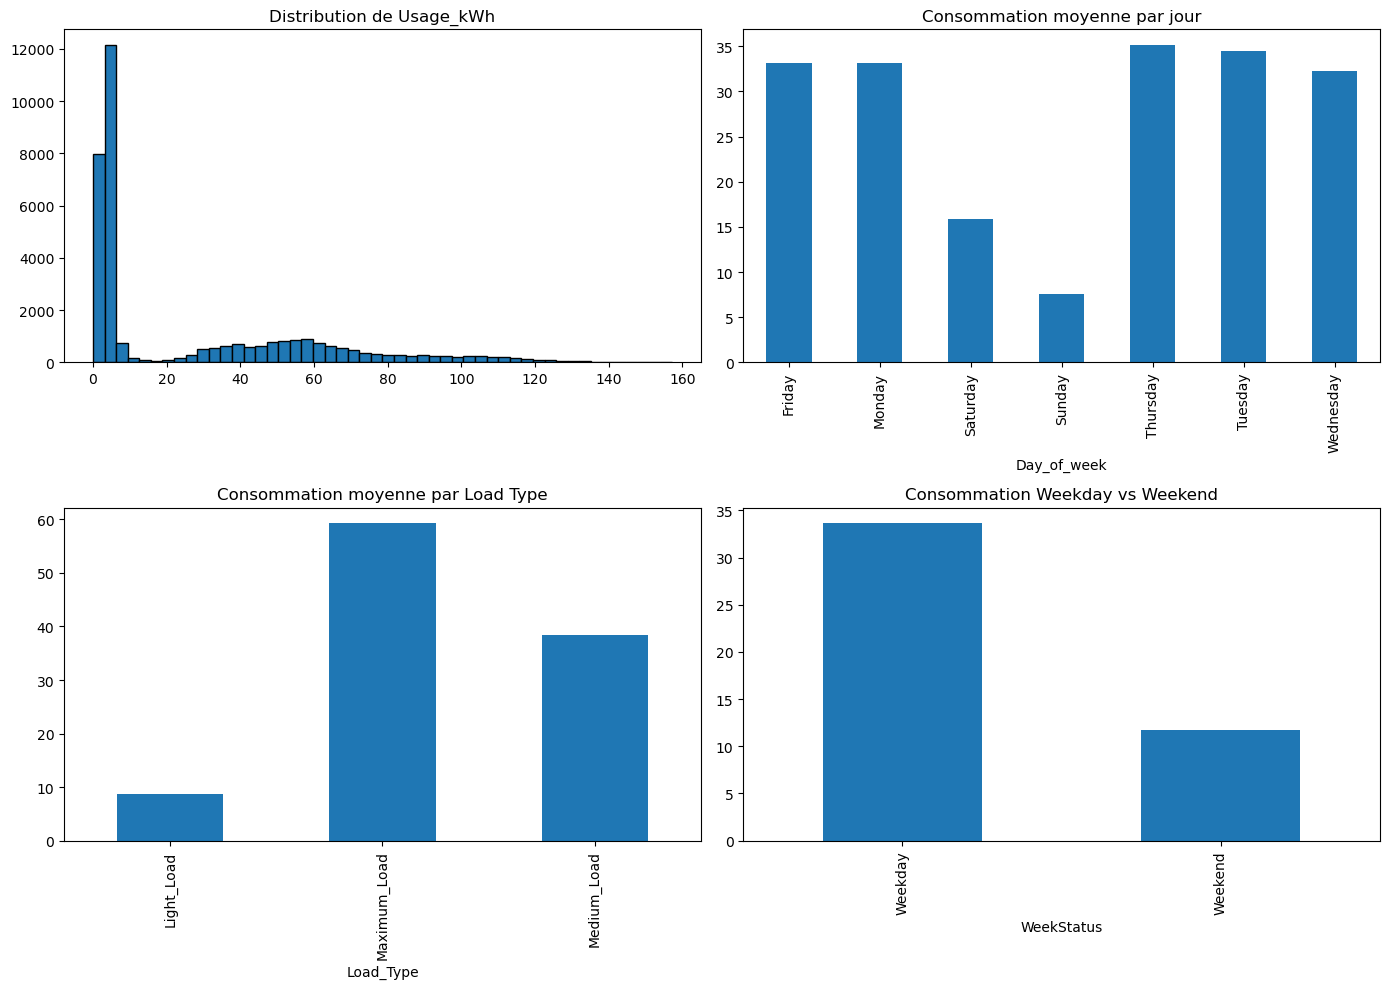

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution de la cible
axes[0, 0].hist(df['Usage_kWh'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution de Usage_kWh')

# 2. Consommation par jour de la semaine
df.groupby('Day_of_week')['Usage_kWh'].mean().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Consommation moyenne par jour')

# 3. Consommation par type de charge
df.groupby('Load_Type')['Usage_kWh'].mean().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Consommation moyenne par Load Type')

# 4. Weekday vs Weekend
df.groupby('WeekStatus')['Usage_kWh'].mean().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Consommation Weekday vs Weekend')

plt.tight_layout()
plt.savefig('exploration_plots.png', dpi=150)
plt.show()

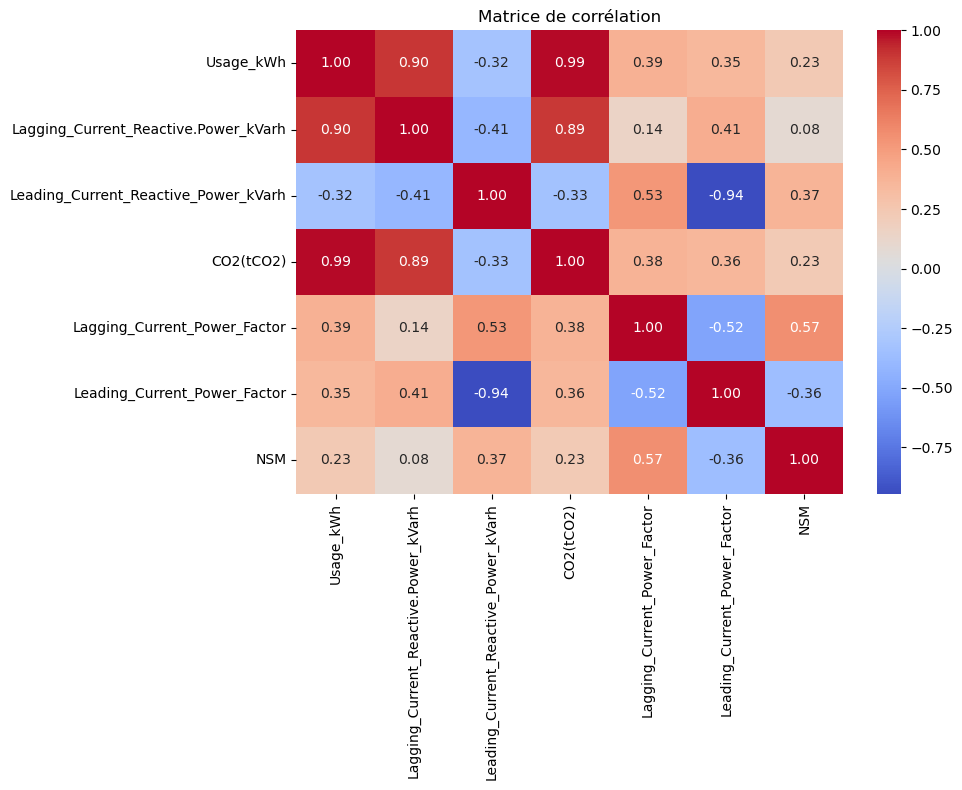

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.show()